#  Retail & Marketing Analytics Project
## Notebook 01: Data Acquisition and Setup

| | |
|---|---|
| **Project** | Retail & Marketing Analytics — Customer Segmentation & Sales Optimization |
| **Notebook** | 01 — Data Acquisition and Setup |
| **Author** | Ayush Kumar Singh |
| **Date** | 13th July 2026 |

### Objectives
- Setup project environment
- Download dataset from Kaggle
- Perform initial data inspection
- Create the project folder structure


## 1. Import Libraries
Import all the core libraries needed for data manipulation, analysis and visualization, and configure display/plot settings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path
import zipfile

# Visualization settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6


## 2. Create Project Folder Structure
Set up a clean, standard project directory layout for raw/processed data, notebooks, scripts, dashboards, outputs and documentation.

In [2]:
# Define folder structure
folders = [
    'data/raw',
    'data/processed',
    'notebooks',
    'scripts',
    'dashboards',
    'outputs/figures',
    'outputs/reports',
    'docs'
]

# Create folders
for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)
    print(f"✓ Created: {folder}")

print("\nProject structure created successfully!")

✓ Created: data/raw
✓ Created: data/processed
✓ Created: notebooks
✓ Created: scripts
✓ Created: dashboards
✓ Created: outputs/figures
✓ Created: outputs/reports
✓ Created: docs

Project structure created successfully!


## 3. Download Dataset from Kaggle (Optional)
Dataset source: [Retail Sales Data with Seasonal Trends & Marketing](https://www.kaggle.com/datasets/abdullah0a/retail-sales-data-with-seasonal-trends-and-marketing)

Uses `kagglehub` to download the dataset and copies the CSV into `data/raw/`.

In [3]:
import kagglehub
import os
import shutil

# Step 1: Download dataset
path = kagglehub.dataset_download("abdullah0a/retail-sales-data-with-seasonal-trends-and-marketing")
print("Downloaded dataset path:", path)

# Step 2: Define new target directory and filename
target_dir = "data/raw"
os.makedirs(target_dir, exist_ok=True)  # create folder if not exist

# (Optional) If you want to rename the main CSV file
new_filename = "retail_sales_data.csv"  # rename as desired

# Step 3: Find the CSV file in downloaded folder
for file in os.listdir(path):
    if file.endswith(".csv"):
        source_file = os.path.join(path, file)
        destination_file = os.path.join(target_dir, new_filename)

        # Copy file (use shutil.move if you prefer moving instead of copying)
        shutil.copy(source_file, destination_file)
        print(f"Copied file to: {destination_file}")
        break
else:
    print("No CSV file found in the downloaded dataset folder.")

print("Place CSV file in:", target_dir)

Downloaded dataset path: /Users/ayushkumarsingh/.cache/kagglehub/datasets/abdullah0a/retail-sales-data-with-seasonal-trends-and-marketing/versions/2
Copied file to: data/raw/retail_sales_data.csv
Place CSV file in: data/raw


## 4. Load Dataset
Load the dataset from `data/raw/retail_sales_data.csv`. If the file isn't found (e.g. Kaggle download was skipped), a realistic synthetic sample dataset of 10,000 records is generated instead so the pipeline can still run end-to-end.

In [4]:
# Option 1: Load from Kaggle download
try:
    df_sales = pd.read_csv('data/raw/retail_sales_data.csv')
    print("\n✓ Dataset loaded successfully from Kaggle!")
except FileNotFoundError:
    print("\n Dataset not found. Creating sample data for demonstration...")

    # Create sample dataset for demonstration
    np.random.seed(42)
    n_records = 10000

    # Sample data generation
    df_sales = pd.DataFrame({
        'Order_ID': [f'ORD{str(i).zfill(6)}' for i in range(1, n_records+1)],
        'Order_Date': pd.date_range(start='2022-01-01', periods=n_records, freq='H'),
        'Ship_Date': pd.date_range(start='2022-01-02', periods=n_records, freq='H'),
        'Customer_ID': [f'CUST{np.random.randint(1, 2000):04d}' for _ in range(n_records)],
        'Customer_Name': [f'Customer_{i}' for i in np.random.randint(1, 2000, n_records)],
        'Segment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], n_records, p=[0.5, 0.3, 0.2]),
        'Region': np.random.choice(['East', 'West', 'Central', 'South'], n_records, p=[0.3, 0.25, 0.25, 0.2]),
        'Product_ID': [f'PROD{np.random.randint(1, 500):04d}' for _ in range(n_records)],
        'Product_Category': np.random.choice(['Electronics', 'Furniture', 'Office Supplies', 'Clothing'],
                                            n_records, p=[0.3, 0.2, 0.3, 0.2]),
        'Product_Sub_Category': np.random.choice(['Phones', 'Chairs', 'Paper', 'Accessories', 'Tables',
                                                  'Binders', 'Appliances', 'Shirts'], n_records),
        'Product_Name': [f'Product_{i}' for i in np.random.randint(1, 500, n_records)],
        'Sales': np.random.gamma(2, 50, n_records) + 10,
        'Quantity': np.random.randint(1, 10, n_records),
        'Discount': np.random.choice([0, 0.1, 0.15, 0.2, 0.25], n_records, p=[0.4, 0.2, 0.2, 0.15, 0.05]),
        'Profit': np.random.normal(20, 30, n_records),
        'Shipping_Cost': np.random.gamma(1.5, 3, n_records) + 2,
        'Order_Priority': np.random.choice(['Low', 'Medium', 'High', 'Critical'], n_records, p=[0.3, 0.4, 0.2, 0.1])
    })

    # Add some calculated fields
    df_sales['Unit_Price'] = df_sales['Sales'] / df_sales['Quantity']
    df_sales['Revenue'] = df_sales['Sales']

    # Add some missing values for realistic scenario
    df_sales.loc[np.random.choice(df_sales.index, 50, replace=False), 'Customer_Name'] = np.nan
    df_sales.loc[np.random.choice(df_sales.index, 30, replace=False), 'Profit'] = np.nan

    # Save sample data
    df_sales.to_csv('data/raw/retail_sales_data.csv', index=False)
    print("✓ Sample dataset created and saved!")


✓ Dataset loaded successfully from Kaggle!


## 5. Initial Data Inspection
Take a first look at the dataset: shape, sample rows, column info and data types.

In [5]:
print("\n" + "="*80)
print("INITIAL DATA INSPECTION")
print("="*80)

# Dataset shape
print(f"\n Dataset Shape: {df_sales.shape[0]:,} rows × {df_sales.shape[1]} columns")

# First few rows
print("\n First 5 Rows:")
print(df_sales.head())

# Last few rows
print("\n Last 5 Rows:")
print(df_sales.tail())

# Column information
print("\n Column Information:")
print(df_sales.info())

# Data types
print("\n Data Types:")
print(df_sales.dtypes)


INITIAL DATA INSPECTION

 Dataset Shape: 30,000 rows × 9 columns

 First 5 Rows:
   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0              0.00             2.00  
1              1.00             4.00  
2              0.00      

## 6. Basic Statistics
Summarize numerical columns with descriptive statistics and preview the most frequent values in the leading categorical columns.

In [6]:
print("\n" + "="*80)
print("BASIC STATISTICAL SUMMARY")
print("="*80)

# Numerical columns summary
print("\n Numerical Columns Statistics:")
print(df_sales.describe())

# Categorical columns summary
print("\n Categorical Columns Summary:")
categorical_cols = df_sales.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # First 5 categorical columns
    print(f"\n{col}:")
    print(df_sales[col].value_counts().head())


BASIC STATISTICAL SUMMARY

 Numerical Columns Statistics:
          YEAR    MONTH  RETAIL SALES  RETAIL TRANSFERS  WAREHOUSE SALES
count 30000.00 30000.00      29999.00          30000.00         30000.00
mean   2020.00     3.91          6.94              6.59            27.43
std       0.00     2.84         33.08             27.88           272.17
min    2020.00     1.00         -0.42             -6.00         -3999.00
25%    2020.00     1.00          0.00              0.00             0.00
50%    2020.00     3.00          0.16              0.00             1.00
75%    2020.00     7.00          2.92              3.00             6.00
max    2020.00     9.00       2739.00           1507.00         18317.00

 Categorical Columns Summary:

SUPPLIER:
SUPPLIER
THE COUNTRY VINTNER, LLC DBA WINEBOW    2041
REPUBLIC NATIONAL DISTRIBUTING CO       1832
SOUTHERN GLAZERS WINE AND SPIRITS       1304
LEGENDS LTD                             1227
MONSIEUR TOUTON SELECTION               1131
Name: co

## 7. Data Quality Assessment
Check for missing values, duplicate rows, and the number of unique values per column — these findings drive the cleaning strategy in Notebook 02.

In [7]:
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Missing values
print("\n Missing Values:")
missing_data = pd.DataFrame({
    'Column': df_sales.columns,
    'Missing_Count': df_sales.isnull().sum().values,
    'Missing_Percentage': (df_sales.isnull().sum().values / len(df_sales) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# Duplicate rows
duplicates = df_sales.duplicated().sum()
print(f"\n Duplicate Rows: {duplicates} ({(duplicates/len(df_sales)*100):.2f}%)")

# Unique values per column
print("\n Unique Values per Column:")
unique_counts = pd.DataFrame({
    'Column': df_sales.columns,
    'Unique_Count': [df_sales[col].nunique() for col in df_sales.columns],
    'Data_Type': df_sales.dtypes.values
})
print(unique_counts)


DATA QUALITY ASSESSMENT

 Missing Values:
         Column  Missing_Count  Missing_Percentage
2      SUPPLIER             33                0.11
6  RETAIL SALES              1                0.00

 Duplicate Rows: 0 (0.00%)

 Unique Values per Column:
             Column  Unique_Count Data_Type
0              YEAR             1     int64
1             MONTH             4     int64
2          SUPPLIER           290       str
3         ITEM CODE         15668       str
4  ITEM DESCRIPTION         15732       str
5         ITEM TYPE             8       str
6      RETAIL SALES          3657   float64
7  RETAIL TRANSFERS           542   float64
8   WAREHOUSE SALES          1032   float64


## 8. Initial Visualizations
Visualize the top columns with missing values and the overall distribution of data types across the dataset.


CREATING INITIAL VISUALIZATIONS
✓ Saved: 01_missing_values.png


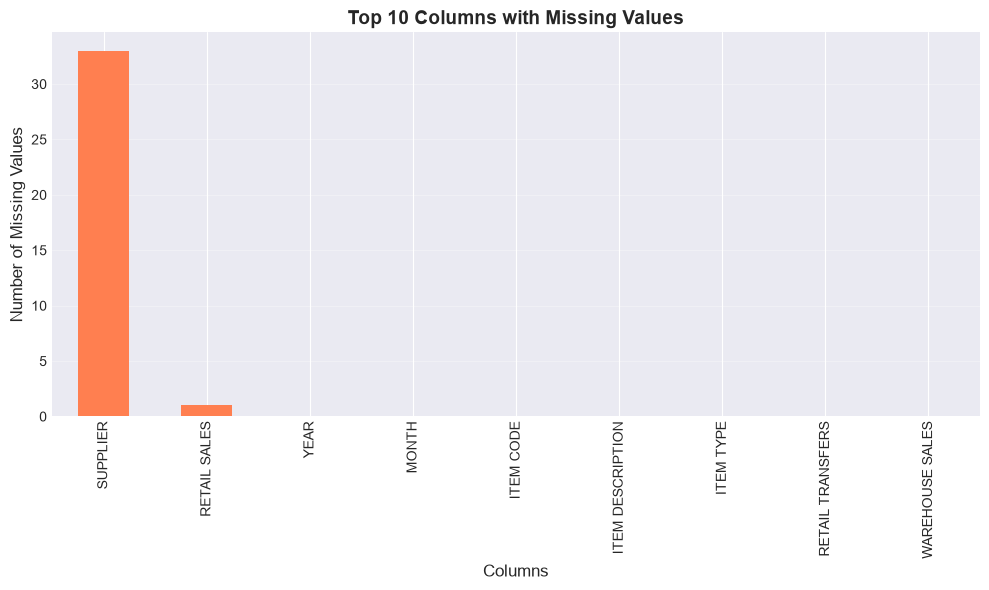

In [8]:
print("\n" + "="*80)
print("CREATING INITIAL VISUALIZATIONS")
print("="*80)

# Create visualization directory if not exists
os.makedirs('outputs/figures', exist_ok=True)

# 1. Missing values visualization
fig, ax = plt.subplots(figsize=(10, 6))
missing_data_plot = df_sales.isnull().sum().sort_values(ascending=False)[:10]
missing_data_plot.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 10 Columns with Missing Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Number of Missing Values', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/01_missing_values.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_missing_values.png")
plt.show()

✓ Saved: 02_data_types_distribution.png


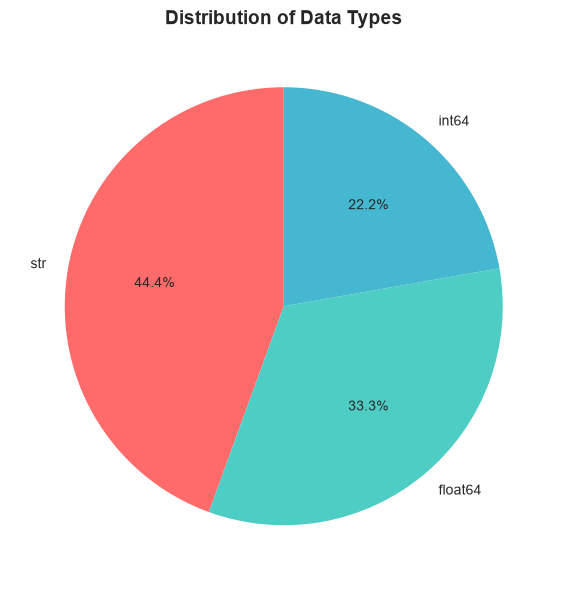

In [9]:
# 2. Data types distribution
fig, ax = plt.subplots(figsize=(8, 6))
dtype_counts = df_sales.dtypes.value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
ax.pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%',
       startangle=90, colors=colors)
ax.set_title('Distribution of Data Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_data_types_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_data_types_distribution.png")
plt.show()

## 9. Save Initial Inspection Report
Compile the key findings from this notebook into a text report saved under `outputs/reports/`.

In [10]:
# Create comprehensive report
report = f"""
RETAIL & MARKETING ANALYTICS PROJECT
Initial Data Inspection Report
{'='*80}

1. DATASET OVERVIEW
   - Total Records: {df_sales.shape[0]:,}
   - Total Columns: {df_sales.shape[1]}
   - Memory Usage: {df_sales.memory_usage(deep=True).sum() / 1024**2:.2f} MB

2. DATA QUALITY SUMMARY
   - Missing Values: {df_sales.isnull().sum().sum():,} cells ({(df_sales.isnull().sum().sum()/(df_sales.shape[0]*df_sales.shape[1])*100):.2f}%)
   - Duplicate Rows: {duplicates} ({(duplicates/len(df_sales)*100):.2f}%)
   - Complete Rows: {df_sales.dropna().shape[0]:,} ({(df_sales.dropna().shape[0]/len(df_sales)*100):.2f}%)

3. COLUMN TYPES
   - Numerical: {len(df_sales.select_dtypes(include=[np.number]).columns)}
   - Categorical/Object: {len(df_sales.select_dtypes(include=['object']).columns)}
   - DateTime: {len(df_sales.select_dtypes(include=['datetime64']).columns)}

4. NEXT STEPS
   ✓ Proceed to Data Cleaning (Notebook 02)
   - Handle missing values
   - Remove duplicates
   - Convert data types
   - Handle outliers
   - Feature engineering

Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

# Save report
with open('outputs/reports/01_initial_inspection_report.txt', 'w') as f:
    f.write(report)

print("\n✓ Initial inspection report saved!")
print(report)


✓ Initial inspection report saved!

RETAIL & MARKETING ANALYTICS PROJECT
Initial Data Inspection Report

1. DATASET OVERVIEW
   - Total Records: 30,000
   - Total Columns: 9
   - Memory Usage: 9.48 MB

2. DATA QUALITY SUMMARY
   - Missing Values: 34 cells (0.01%)
   - Duplicate Rows: 0 (0.00%)
   - Complete Rows: 29,967 (99.89%)

3. COLUMN TYPES
   - Numerical: 5
   - Categorical/Object: 4
   - DateTime: 0

4. NEXT STEPS
   ✓ Proceed to Data Cleaning (Notebook 02)
   - Handle missing values
   - Remove duplicates
   - Convert data types
   - Handle outliers
   - Feature engineering

Report Generated: 2026-07-15 14:20:54



## 10. Save Checkpoint
Persist the initially loaded dataset as a checkpoint so downstream notebooks can reproduce this exact starting point.

In [11]:
# Save initial loaded data for reference
df_sales.to_csv('data/raw/original_data_checkpoint.csv', index=False)
print("\n✓ Data checkpoint saved: data/raw/original_data_checkpoint.csv")

print("\n" + "="*80)
print("NOTEBOOK 01 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Open Notebook 02 - Data Cleaning and Preprocessing")
print("="*80)


✓ Data checkpoint saved: data/raw/original_data_checkpoint.csv

NOTEBOOK 01 COMPLETED SUCCESSFULLY!

 Next Step: Open Notebook 02 - Data Cleaning and Preprocessing


---
### Summary

In this notebook we:
- Set up the project folder structure
- Downloaded (or simulated) the retail sales dataset
- Performed an initial inspection of shape, types, and samples
- Assessed data quality (missing values, duplicates, uniqueness)
- Saved an inspection report and a raw data checkpoint


